# TASK 7. SIMILARITY BENCHMARKING

## Objective

This task compares three similarity metrics used in vector search:

- Cosine Similarity
- Dot Product
- Euclidean Distance

The objective is to understand how different similarity metrics measure relationships between text embeddings.

## Notebook Structure

1. Objective
2. Install Libraries
3. Import Libraries
4. Create Sample Documents
5. Generate Embeddings
6. Compute Similarity Metrics
7. Compare Results
8. Visualization
9. Analysis
10. Conclusion

## Step 1: Install Libraries

In [1]:
!pip install openai python-dotenv scikit-learn matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Import Libraries

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dotenv import load_dotenv
from openai import OpenAI

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

## Step 3: Load API

In [3]:

load_dotenv()

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("API_KEY")

# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key = openai_api_key)
print("\nOpenAI client successfully configured.")

# Let's view the first few characters in the key
print(openai_api_key[:3])


OpenAI client successfully configured.
sk-


## Step 4: Sample Documents

In [17]:
documents = [
    "Machine learning learns patterns from data.",
    "Artificial intelligence enables intelligent systems.",
    "Deep learning uses neural networks.",
    "Football is a popular sport.",
    "Electric vehicles reduce pollution."
]

query = "How do computers learn from data?"

## Step 5: Generate Embeddings

In [18]:
embeddings = []

for doc in documents:
    response = openai_client.embeddings.create(
        model="text-embedding-3-small",
        input=doc
    )

    embeddings.append(response.data[0].embedding)

query_embedding = openai_client.embeddings.create(
    model="text-embedding-3-small",
    input=query
).data[0].embedding

## Step 6: Calculate Similarities

In [6]:
results = []

query_vector = np.array(query_embedding)

for i, emb in enumerate(embeddings):

    doc_vector = np.array(emb)

    cosine = cosine_similarity(
        [query_vector],
        [doc_vector]
    )[0][0]

    dot_product = np.dot(
        query_vector,
        doc_vector
    )

    euclidean_distance = euclidean(
        query_vector,
        doc_vector
    )

    results.append([
        documents[i],
        cosine,
        dot_product,
        euclidean_distance
    ])

## Create DataFrame

In [19]:
df = pd.DataFrame(
    results,
    columns=[
        "Document",
        "Cosine Similarity",
        "Dot Product",
        "Euclidean Distance"
    ]
)
df = df.round(4)

df

,Document,Cosine Similarity,Dot Product,Euclidean Distance
0,Machine learning learns patterns from data.,0.6642,0.6642,0.8195
1,Artificial intelligence enables intelligent sy...,0.3575,0.3575,1.1336
2,Football is a popular sport.,0.0118,0.0118,1.4056
3,Electric vehicles reduce pollution.,0.0845,0.0845,1.3531


## Step 7: Compare Results

In [20]:
df = df.sort_values(
    by="Cosine Similarity",
    ascending=False
)

df

,Document,Cosine Similarity,Dot Product,Euclidean Distance
0,Machine learning learns patterns from data.,0.6642,0.6642,0.8195
1,Artificial intelligence enables intelligent sy...,0.3575,0.3575,1.1336
3,Electric vehicles reduce pollution.,0.0845,0.0845,1.3531
2,Football is a popular sport.,0.0118,0.0118,1.4056


## Visualization

## 1.Cosine Similarity 

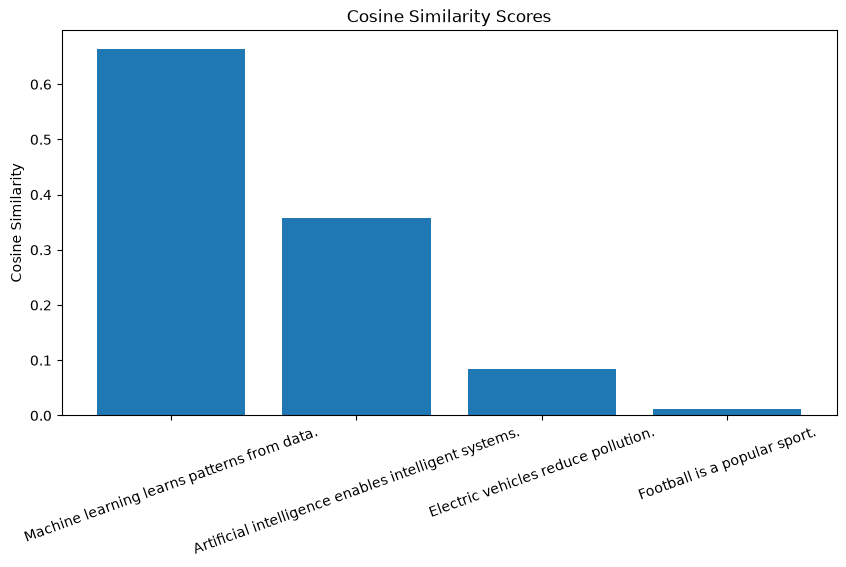

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Document"],
    df["Cosine Similarity"]
)

plt.xticks(rotation=20)

plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity Scores")
plt.show()

## 2.Dot Product

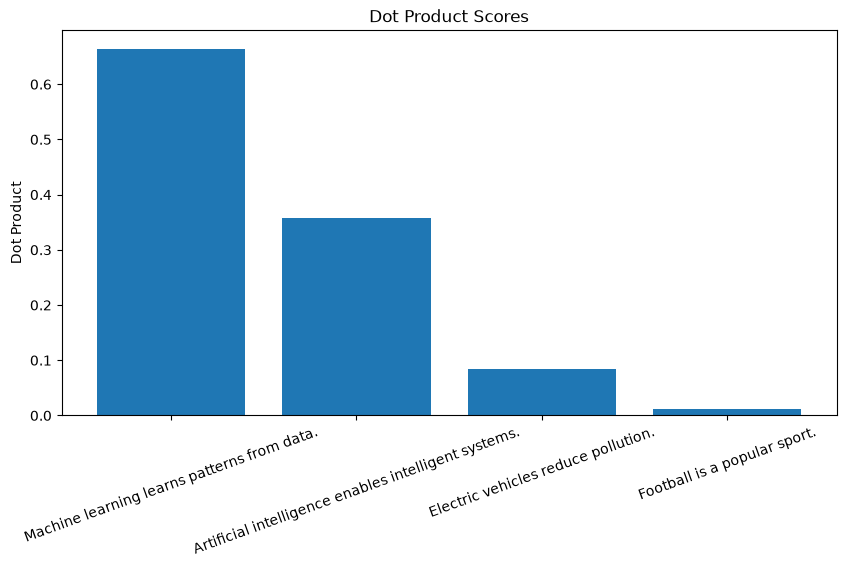

In [22]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Document"],
    df["Dot Product"]
)

plt.xticks(rotation=20)
plt.ylabel("Dot Product")
plt.title("Dot Product Scores")
plt.show()

## 3.Euclidean Distance

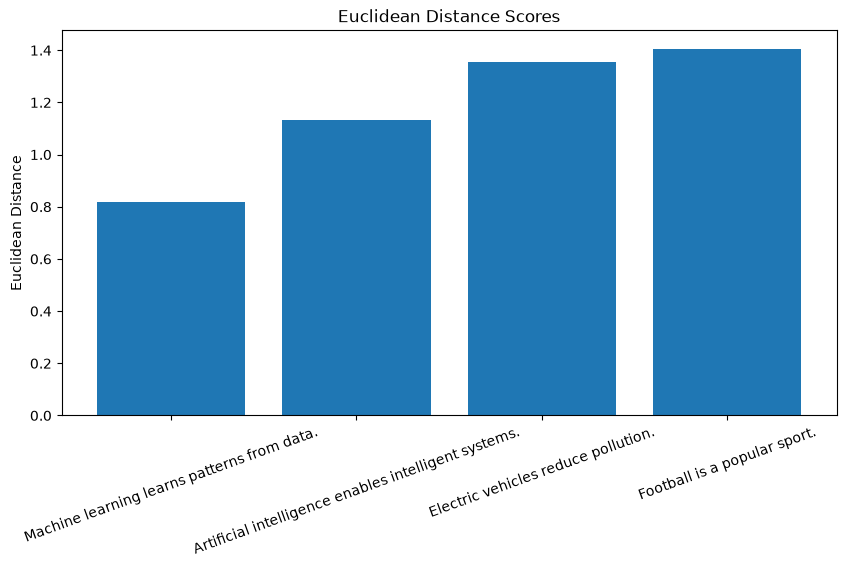

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Document"],
    df["Euclidean Distance"]
)

plt.xticks(rotation=20)
plt.ylabel("Euclidean Distance")
plt.title("Euclidean Distance Scores")
plt.show()

## Analysis

The query "How do computers learn from data?" was compared against all document embeddings using three similarity metrics.

### Cosine Similarity

- Measures the angle between vectors.
- Higher values indicate greater semantic similarity.
- Most widely used in vector databases.

### Dot Product

- Measures both vector direction and magnitude.
- Larger values indicate stronger similarity.

### Euclidean Distance

- Measures the physical distance between vectors.
- Smaller values indicate greater similarity.

The machine learning and artificial intelligence documents achieved higher similarity scores because they are semantically related to the query.

Unrelated topics such as sports and electric vehicles produced lower similarity scores.

This demonstrates how embedding vectors capture semantic meaning rather than relying solely on exact keyword matching.

## Conclusion

Cosine similarity provided the most meaningful semantic comparison between text embeddings.

Dot product also performed well but depends on vector magnitude.

Euclidean distance measured physical distance between vectors and is less commonly used for semantic search.

Most vector databases such as Chroma, Pinecone, Weaviate, and FAISS primarily use cosine similarity for retrieval tasks.